# 2-Triangle SLSQP — Solver Engineering

Companion to [03_demos.ipynb](03_demos.ipynb). That notebook showed that 2-triangle SLSQP stalls on the `01c_20x40_edges` case with `success=False`, status 8 (*"Positive directional derivative for linesearch"*) at `nit=42`, leaving 14 local folds and 109 global quad intersections. This notebook is a focused deep-dive on **why** it stalls and **how** to fix it.

Two independent fixes are tested, then combined:

- **Part 4**: diagnose the exit status and try perturbation warm-start.
- **Part 5**: derive, validate, and test the analytical constraint Jacobian — eliminates finite-difference noise in the QP sub-problem.

The combined fix (analytical Jacobian + warm-start perturbation) fully clears the case.

In [1]:
import os, sys, time
sys.path.insert(0, os.path.abspath('../..'))

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize, NonlinearConstraint
from scipy.sparse import csr_matrix

from dvfopt import DEFAULT_PARAMS, jacobian_det2D
from dvfopt.jacobian import triangle_sign_det2D, triangle_sign_areas2D
from dvfopt.jacobian.triangle_sign import _triangle_areas_2d
from dvfopt.jacobian.intersection import has_quad_self_intersections, _quads_intersect
from dvfopt.core.objective import objective_euc

from test_cases import make_deformation

THRESHOLD = DEFAULT_PARAMS['threshold']  # 0.01
print(f'threshold = {THRESHOLD}')

threshold = 0.01


In [2]:
def _forward_jdet_2d(dy, dx):
    ddx_dx = dx[:-1, 1:]  - dx[:-1, :-1]
    ddy_dy = dy[1:,  :-1] - dy[:-1, :-1]
    ddx_dy = dx[1:,  :-1] - dx[:-1, :-1]
    ddy_dx = dy[:-1, 1:]  - dy[:-1, :-1]
    return (1 + ddx_dx) * (1 + ddy_dy) - ddx_dy * ddy_dx

def measure(phi):
    jd = np.squeeze(jacobian_det2D(phi))
    fd = _forward_jdet_2d(phi[0], phi[1])
    tri = triangle_sign_areas2D(phi)
    return dict(
        jd=jd, fd=fd, tri=tri,
        n_cd=int((jd <= 0).sum()),
        n_fd=int((fd <= 0).sum()),
        n_tr=int((tri <= 0).sum()),
        min_cd=float(jd.min()), min_fd=float(fd.min()), min_tr=float(tri.min()),
    )


def _triangle_flat(dy_, dx_):
    T1, T2 = _triangle_areas_2d(dy_, dx_)
    return np.concatenate([T1.flatten(), T2.flatten()])


def list_intersecting_quads(phi):
    dy, dx = phi[0], phi[1]
    H, W = dy.shape
    nr, nc = H - 1, W - 1
    if nr <= 0 or nc <= 0:
        return []
    rows = np.arange(H, dtype=float)[:, None]
    cols = np.arange(W, dtype=float)[None, :]
    Y = rows + dy; X = cols + dx
    y_tl, x_tl = Y[:-1, :-1], X[:-1, :-1]
    y_tr, x_tr = Y[:-1, 1:],  X[:-1, 1:]
    y_br, x_br = Y[1:,  1:],  X[1:,  1:]
    y_bl, x_bl = Y[1:,  :-1], X[1:,  :-1]
    aabb_ymin = np.minimum(np.minimum(y_tl, y_tr), np.minimum(y_bl, y_br))
    aabb_ymax = np.maximum(np.maximum(y_tl, y_tr), np.maximum(y_bl, y_br))
    aabb_xmin = np.minimum(np.minimum(x_tl, x_tr), np.minimum(x_bl, x_br))
    aabb_xmax = np.maximum(np.maximum(x_tl, x_tr), np.maximum(x_bl, x_br))
    corners = np.stack([
        np.stack([y_tl.ravel(), x_tl.ravel()], axis=1),
        np.stack([y_tr.ravel(), x_tr.ravel()], axis=1),
        np.stack([y_br.ravel(), x_br.ravel()], axis=1),
        np.stack([y_bl.ravel(), x_bl.ravel()], axis=1),
    ], axis=1)
    ymin_flat = aabb_ymin.ravel(); ymax_flat = aabb_ymax.ravel()
    xmin_flat = aabb_xmin.ravel(); xmax_flat = aabb_xmax.ravel()
    n_quads = nr * nc
    pairs = []
    for i in range(n_quads):
        ri, ci = divmod(i, nc)
        for j in range(i + 1, n_quads):
            rj, cj = divmod(j, nc)
            if abs(ri - rj) <= 1 and abs(ci - cj) <= 1: continue
            if (ymin_flat[i] > ymax_flat[j] or ymax_flat[i] < ymin_flat[j]
                    or xmin_flat[i] > xmax_flat[j] or xmax_flat[i] < xmin_flat[j]): continue
            if _quads_intersect(corners[i], corners[j]):
                pairs.append(((ri, ci), (rj, cj)))
    return pairs

## Setup — reproduce the stuck `01c_20x40_edges` iterate

Load the field, run the baseline SLSQP (finite-difference Jacobian, default `maxiter=500`). This matches the baseline from `03_demos.ipynb` Part 2 so the rest of this notebook has the same starting point.

In [3]:
CASE_KEY = '01c_20x40_edges'
deformation, *_ = make_deformation(CASE_KEY)
phi_init = np.stack([deformation[1, 0], deformation[2, 0]])
m0 = measure(phi_init)

_, H_, W_ = phi_init.shape
pixels = H_ * W_

def unpack(z):
    return z[pixels:].reshape(H_, W_), z[:pixels].reshape(H_, W_)

def constr(z):
    dy_, dx_ = unpack(z)
    return _triangle_flat(dy_, dx_)

z0_init = np.concatenate([phi_init[1].flatten(), phi_init[0].flatten()])

t0 = time.time()
res_base = minimize(
    lambda z: objective_euc(z, z0_init),
    z0_init.copy(),
    jac=True,
    method='SLSQP',
    constraints=[NonlinearConstraint(constr, THRESHOLD, np.inf)],
    options={'maxiter': 500, 'disp': False},
)
t_base = time.time() - t0
dy_b, dx_b = unpack(res_base.x)
phi_out = np.stack([dy_b, dx_b])
m1 = measure(phi_out)
qi_init = list_intersecting_quads(phi_init)
qi_out = list_intersecting_quads(phi_out)

runs = {
    CASE_KEY: dict(
        phi_init=phi_init, phi_out=phi_out,
        m0=m0, m1=m1, qi_init=qi_init, qi_out=qi_out,
        info=dict(nit=res_base.nit, time=t_base, success=bool(res_base.success),
                  message=str(res_base.message), status=int(res_base.status)),
        l2=float(np.linalg.norm(phi_out - phi_init)),
    )
}

r = runs[CASE_KEY]; info = r['info']
print(f'shape             : {phi_init[0].shape}   pixels: {pixels}')
print(f'initial neg_TR    : {m0["n_tr"]}    initial QI pairs: {len(qi_init)}')
print(f'SLSQP nit         : {info["nit"]}    time: {info["time"]:.2f}s    status: {info["status"]}')
print(f'SLSQP success     : {info["success"]}   message: {info["message"]}')
print(f'post neg_TR       : {m1["n_tr"]}    post QI pairs: {len(qi_out)}')
print(f'post min_TR       : {m1["min_tr"]:+.5f}   L2 from phi_init: {r["l2"]:.3f}')

Building data for Laplacian Sparse Matrix A (optimized)
Creating Laplacian Sparse Matrix A


shape             : (20, 40)   pixels: 800
initial neg_TR    : 68    initial QI pairs: 334
SLSQP nit         : 42    time: 104.91s    status: 8
SLSQP success     : False   message: Positive directional derivative for linesearch
post neg_TR       : 14    post QI pairs: 109
post min_TR       : -0.30379   L2 from phi_init: 20.216


### Pre-optimization fold overview

Three views of the initial 01c_20x40_edges field before any SLSQP run:

- **Left** — warped quad grid with every cell having `min(T1, T2) ≤ 0` outlined in dark blue. The folds concentrate near the left and right edges, characteristic of this test case (large opposite displacements at the image borders).
- **Middle** — central-diff Jdet heatmap. Shows which pixels the symmetric stencil detects as folded.
- **Right** — `min(T1, T2)` heatmap. Shows the geometric 2-triangle fold structure — more local, catches cells CD misses.

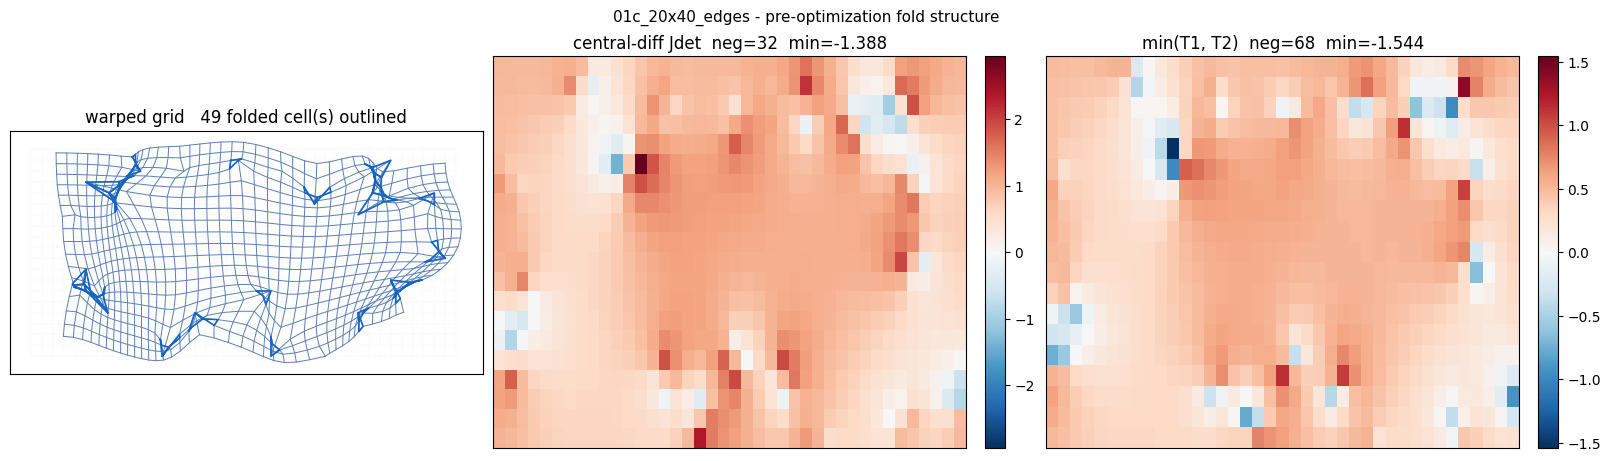

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), layout='constrained')

# --- warped grid with folded cells outlined -------------------------
ax = axes[0]
H_p, W_p = phi_init[0].shape
yy_p, xx_p = np.mgrid[:H_p, :W_p]
gx = xx_p + phi_init[1]; gy = yy_p + phi_init[0]
for i in range(H_p):
    ax.plot(xx_p[i], yy_p[i], color='#f4f4f4', lw=0.3)
for j in range(W_p):
    ax.plot(xx_p[:, j], yy_p[:, j], color='#f4f4f4', lw=0.3)
for i in range(H_p):
    ax.plot(gx[i], gy[i], color='#5b7fb5', lw=0.7)
for j in range(W_p):
    ax.plot(gx[:, j], gy[:, j], color='#5b7fb5', lw=0.7)
tri_init = triangle_sign_areas2D(phi_init)
bad_init = np.argwhere(tri_init.min(axis=0) <= 0)
for (cy, cx) in bad_init:
    px = [gx[cy, cx], gx[cy, cx+1], gx[cy+1, cx+1], gx[cy+1, cx], gx[cy, cx]]
    py = [gy[cy, cx], gy[cy, cx+1], gy[cy+1, cx+1], gy[cy+1, cx], gy[cy, cx]]
    ax.plot(px, py, color='#1565c0', lw=1.2)
ax.set_aspect('equal'); ax.invert_yaxis()
ax.set_title(f'warped grid   {len(bad_init)} folded cell(s) outlined')
ax.set_xticks([]); ax.set_yticks([])

# --- central-diff Jdet heatmap ---------------------------------------
jd0 = m0['jd']
vmax_cd = float(max(abs(jd0).max(), 1.0))
im1 = axes[1].imshow(jd0, cmap='RdBu_r', vmin=-vmax_cd, vmax=vmax_cd, aspect='auto')
axes[1].set_title(f"central-diff Jdet  neg={m0['n_cd']}  min={m0['min_cd']:+.3f}")
axes[1].set_xticks([]); axes[1].set_yticks([])
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

# --- min(T1, T2) heatmap ---------------------------------------------
tri_min0 = tri_init.min(axis=0)
vmax_tr = float(max(abs(tri_min0).max(), 1.0))
im2 = axes[2].imshow(tri_min0, cmap='RdBu_r', vmin=-vmax_tr, vmax=vmax_tr, aspect='auto')
axes[2].set_title(f"min(T1, T2)  neg={m0['n_tr']}  min={m0['min_tr']:+.3f}")
axes[2].set_xticks([]); axes[2].set_yticks([])
fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

plt.suptitle(f'{CASE_KEY} - pre-optimization fold structure', fontsize=11)
plt.show()

### Baseline SLSQP with central-diff constraint

The three variants in Parts 4-5 below all use the same **2-triangle constraint**; they differ only in the Jacobian method (finite-diff vs. analytical) and the warm-start. For a different kind of comparison — a *different constraint formulation* altogether — we also run classic central-difference SLSQP: constraint is `jacobian_det2D(phi) ≥ threshold` per pixel.

On the 7×7 bowtie (see `../shoelace-artifact-example.ipynb`) CD-SLSQP sees 0 folds and does nothing. On `01c_20x40_edges` the fold magnitudes are large enough that CD *does* see 32 of the 68 geometric folds, so SLSQP has something to correct. The question: how far can CD push it, and what does the 2-triangle check say about the result?

In [5]:
# Central-difference SLSQP — same data term and same solver, different constraint.
from dvfopt.jacobian.numpy_jdet import _numpy_jdet_2d

def _cd_flat(dy_, dx_):
    return _numpy_jdet_2d(dy_, dx_).flatten()

t0 = time.time()
res_cd = minimize(
    lambda z: objective_euc(z, z0_init),
    z0_init.copy(),
    jac=True,
    method='SLSQP',
    constraints=[NonlinearConstraint(
        lambda z: _cd_flat(*unpack(z)), THRESHOLD, np.inf
    )],
    options={'maxiter': 500, 'disp': False},
)
t_cd = time.time() - t0
dy_cd, dx_cd = unpack(res_cd.x)
phi_cd = np.stack([dy_cd, dx_cd])
m_cd = measure(phi_cd)
qi_cd = list_intersecting_quads(phi_cd)

print('CD-constraint SLSQP:')
print(f'  nit={res_cd.nit}  time={t_cd:.2f}s  success={res_cd.success}  status={res_cd.status}')
print(f'  message: {res_cd.message}')
print(f'  neg_CD={m_cd["n_cd"]}   neg_FD={m_cd["n_fd"]}   neg_TR={m_cd["n_tr"]}   QI={len(qi_cd)}')
print(f'  min_CD={m_cd["min_cd"]:+.4f}   min_TR={m_cd["min_tr"]:+.4f}')

CD-constraint SLSQP:
  nit=10  time=15.76s  success=True  status=0
  message: Optimization terminated successfully
  neg_CD=0   neg_FD=30   neg_TR=64   QI=327
  min_CD=+0.0100   min_TR=-1.4062


## Part 4 — Why does 2-triangle SLSQP stall on `01c_20x40_edges`?

The 20×40 case is the only one where SLSQP fails to drive `neg_TR` to zero. The run stopped at `nit=42` (well below the `maxiter=500` cap) with 14 local folds remaining and 109 global intersecting pairs. Four candidate causes, tested below:

1. **Solver convergence flag.** Did SLSQP think it had converged (`success=True`), or did it fail numerically (`success=False`)? Print the exit message.
2. **Iteration cap is fine — solver gave up early.** Re-run with `maxiter=2000` and a looser `ftol` to see if the remaining folds clear.
3. **Geometry of the residual folds.** Plot *where* the remaining `neg_TR` cells are in the grid. If they cluster near the image edges, the fold topology is genuinely constrained by the grid boundary — there's no nearby interior room to unfold into, and SLSQP is stuck against the `x,y ∈ [0, H·W)` wall.
4. **Constraint-vs-displacement tug-of-war.** The quadratic data term `½‖φ − φ₀‖²` penalises any displacement from the initial (folded) field. If the fix requires a large update, the QP sub-problems keep proposing small corrections that never clear threshold. A re-run with looser penalty or an initial perturbation that breaks symmetry could unstick it.

In [6]:
key = '01c_20x40_edges'
r = runs[key]
info = r['info']
m1 = r['m1']
tri_out = m1['tri']          # (2, H-1, W-1) signed areas
tri_min_out = tri_out.min(axis=0)
Hc, Wc = tri_min_out.shape

print(f'SLSQP exit for {key}:')
print(f"  nit        = {info['nit']}")
print(f"  success    = {info['success']}")
print(f"  status     = {info['status']}  (0 = OK, 9 = maxiter, 4 = inequality constraint incompatible, ...)")
print(f"  message    = {info['message']}")
print(f"  time       = {info['time']:.2f}s")
print(f"  neg_TR out = {m1['n_tr']}   min_TR out = {m1['min_tr']:+.5f}")
print()

bad_cells = np.argwhere(tri_min_out <= 0)
print(f'{len(bad_cells)} cells still have at least one triangle ≤ 0 post-correction.')
col_hist = np.bincount(bad_cells[:, 1], minlength=Wc)
row_hist = np.bincount(bad_cells[:, 0], minlength=Hc)
print(f'  by column (len {Wc}): {col_hist.tolist()}')
print(f'  by row    (len {Hc}): {row_hist.tolist()}')

SLSQP exit for 01c_20x40_edges:
  nit        = 42
  success    = False
  status     = 8  (0 = OK, 9 = maxiter, 4 = inequality constraint incompatible, ...)
  message    = Positive directional derivative for linesearch
  time       = 104.91s
  neg_TR out = 14   min_TR out = -0.30379

12 cells still have at least one triangle ≤ 0 post-correction.
  by column (len 39): [1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 2, 1, 0, 0, 1]
  by row    (len 19): [1, 1, 2, 0, 2, 1, 0, 0, 0, 0, 0, 0, 2, 0, 1, 0, 2, 0, 0]


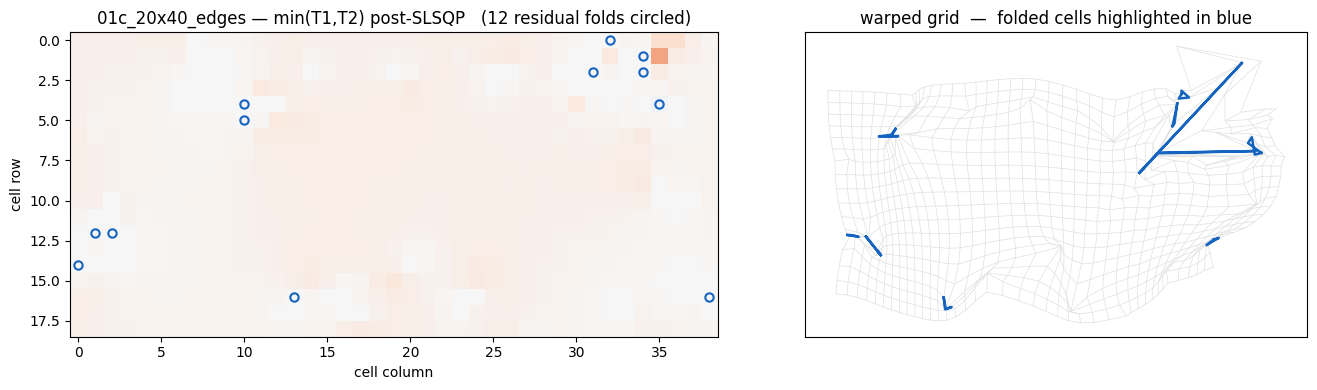

In [7]:
# Where are the residual folds? Heatmap + red overlay on the warped grid.
phi_init = r['phi_init']; phi_out = r['phi_out']
Hh, Ww = phi_init[0].shape

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

vmax = max(abs(m1['tri'].min()), abs(m1['tri'].max()))
axes[0].imshow(tri_min_out, cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='auto')
for (cy, cx) in bad_cells:
    axes[0].plot(cx, cy, 'o', markersize=6, markerfacecolor='none',
                 markeredgecolor='#1565c0', markeredgewidth=1.5)
axes[0].set_title(f'{key} — min(T1,T2) post-SLSQP   ({len(bad_cells)} residual folds circled)')
axes[0].set_xlabel('cell column'); axes[0].set_ylabel('cell row')

yy, xx = np.mgrid[:Hh, :Ww]
gx = xx + phi_out[1]; gy = yy + phi_out[0]
for i in range(Hh):
    axes[1].plot(gx[i], gy[i], color='#e0e0e0', lw=0.5)
for j in range(Ww):
    axes[1].plot(gx[:, j], gy[:, j], color='#e0e0e0', lw=0.5)
for (cy, cx) in bad_cells:
    poly_x = [gx[cy, cx], gx[cy, cx+1], gx[cy+1, cx+1], gx[cy+1, cx], gx[cy, cx]]
    poly_y = [gy[cy, cx], gy[cy, cx+1], gy[cy+1, cx+1], gy[cy+1, cx], gy[cy, cx]]
    axes[1].plot(poly_x, poly_y, color='#1565c0', lw=1.8)
axes[1].set_aspect('equal'); axes[1].invert_yaxis()
axes[1].set_title(f'warped grid  —  folded cells highlighted in blue')
axes[1].set_xticks([]); axes[1].set_yticks([])
plt.tight_layout()
plt.show()

In [8]:
# Test (2): does raising maxiter + loosening ftol unstick it?
# SLSQP's default ftol is 1e-6. Try 1e-8 and double the iteration cap.
phi_init = r['phi_init']
_, H_, W_ = phi_init.shape
pixels = H_ * W_

z0 = np.concatenate([phi_init[1].flatten(), phi_init[0].flatten()])
z0_init = z0.copy()

def unpack(z):
    dx_ = z[:pixels].reshape(H_, W_)
    dy_ = z[pixels:].reshape(H_, W_)
    return dy_, dx_

def constr(z):
    return _triangle_flat(*unpack(z))

t0 = time.time()
res2 = minimize(
    lambda z: objective_euc(z, z0_init),
    z0,
    jac=True,
    method='SLSQP',
    constraints=[NonlinearConstraint(constr, THRESHOLD, np.inf)],
    options={'maxiter': 2000, 'ftol': 1e-10, 'disp': False},
)
dt = time.time() - t0
dy_2, dx_2 = unpack(res2.x)
phi_out2 = np.stack([dy_2, dx_2])
m2 = measure(phi_out2)
qi2 = list_intersecting_quads(phi_out2)

print('Re-run with maxiter=2000, ftol=1e-10:')
print(f"  nit     = {res2.nit}  (original: {info['nit']})")
print(f"  status  = {res2.status}")
print(f"  success = {res2.success}")
print(f"  message = {res2.message}")
print(f"  time    = {dt:.2f}s  (original: {info['time']:.2f}s)")
print(f"  neg_TR  = {m2['n_tr']}   min_TR = {m2['min_tr']:+.5f}   (original: {m1['n_tr']}, {m1['min_tr']:+.5f})")
print(f"  QI      = {len(qi2)}   (original: {len(r['qi_out'])})")

Re-run with maxiter=2000, ftol=1e-10:
  nit     = 42  (original: 42)
  status  = 8
  success = False
  message = Positive directional derivative for linesearch
  time    = 105.38s  (original: 104.91s)
  neg_TR  = 14   min_TR = -0.30379   (original: 14, -0.30379)
  QI      = 109   (original: 109)


In [9]:
# Test (4): tiny initial perturbation to break symmetry + warm-start from the
# stuck iterate. Adds ~0.01 Gaussian noise to the current solution and resumes.
rng = np.random.default_rng(123)
perturb = rng.normal(scale=0.01, size=z0.shape)
z_warm = z0.copy()                 # start from the original stuck init
# Instead, let's try warm-starting from the partly-corrected phi_out +
# noise, so the solver starts already inside the feasible-ish region.
z_warm = np.concatenate([r['phi_out'][1].flatten(),
                         r['phi_out'][0].flatten()]) + perturb

t0 = time.time()
res3 = minimize(
    lambda z: objective_euc(z, z0_init),   # data term STILL anchors to phi_init
    z_warm,
    jac=True,
    method='SLSQP',
    constraints=[NonlinearConstraint(constr, THRESHOLD, np.inf)],
    options={'maxiter': 2000, 'ftol': 1e-10, 'disp': False},
)
dt3 = time.time() - t0
dy_3, dx_3 = unpack(res3.x)
phi_out3 = np.stack([dy_3, dx_3])
m3 = measure(phi_out3)
qi3 = list_intersecting_quads(phi_out3)

print('Warm-start from stuck iterate + 0.01 Gaussian perturbation:')
print(f"  nit     = {res3.nit}")
print(f"  status  = {res3.status}   success = {res3.success}")
print(f"  message = {res3.message}")
print(f"  time    = {dt3:.2f}s")
print(f"  neg_TR  = {m3['n_tr']}   min_TR = {m3['min_tr']:+.5f}")
print(f"  QI      = {len(qi3)}")
print(f"  L2 from phi_init = {float(np.linalg.norm(phi_out3 - phi_init)):.3f}")

Warm-start from stuck iterate + 0.01 Gaussian perturbation:
  nit     = 64
  status  = 0   success = True
  message = Optimization terminated successfully
  time    = 144.65s
  neg_TR  = 0   min_TR = +0.01000
  QI      = 0
  L2 from phi_init = 5.406


## Part 5 — The analytical constraint Jacobian

Instead of letting scipy rediscover `∂g/∂z` by finite-differencing the constraint function 1600 times per iteration, we can write the derivative out by hand. The 2-triangle signed area is a polynomial, so its derivatives are polynomials too.

### Derivation

For a single triangle with vertices `A, B, C`,

```
T = −½ · [ (B.x − A.x)(C.y − A.y) − (B.y − A.y)(C.x − A.x) ]
```

Partial derivatives w.r.t. each vertex coordinate (chain-rule + product rule):

```
∂T/∂A.x =  ½ · (C.y − B.y)
∂T/∂A.y =  ½ · (B.x − C.x)
∂T/∂B.x =  ½ · (A.y − C.y)
∂T/∂B.y =  ½ · (C.x − A.x)
∂T/∂C.x =  ½ · (B.y − A.y)
∂T/∂C.y =  ½ · (A.x − B.x)
```

Six nonzeros per triangle. Every other variable in `z` has derivative **zero** — a triangle only touches its own three vertices.

**Mapping vertices to cells and variables.** For our TR-BL triangulation, cell `(cy, cx)` contains:

- `T1`: vertices `A = TR = pixel (cx+1, cy)`, `B = BL = pixel (cx, cy+1)`, `C = BR = pixel (cx+1, cy+1)`
- `T2`: vertices `A = TL = pixel (cx, cy)`, `B = BL = pixel (cx, cy+1)`, `C = TR = pixel (cx+1, cy)`

Each vertex contributes two nonzeros, one into the `dx` block of `z` and one into the `dy` block. With the packing `z = [dx.flatten() | dy.flatten()]`:

- variable for `dx[py, px]` sits at flat index `py·W + px`
- variable for `dy[py, px]` sits at flat index `H·W + py·W + px`

So each of the `2·nr·nc` constraint rows has exactly **6 nonzeros** and the full sparse Jacobian density is `6·2·nr·nc / (2·nr·nc · 2·H·W) = 3 / (H·W)`. For the 20×40 grid that's ~0.4% — 99.6% of the matrix is zero and is never touched.

In [10]:
from scipy.sparse import coo_matrix, csr_matrix


def triangle_sign_constraint_jac_2d(dy, dx):
    """Analytical Jacobian ∂g/∂z for the 2-triangle constraint.

    Constraint layout (matches `_triangle_flat`):
        row 0 .. nr*nc - 1           = T1[cell (cy, cx)]  flattened row-major
        row nr*nc .. 2*nr*nc - 1     = T2[cell (cy, cx)]  flattened row-major

    Variable layout (matches `unpack` in the SLSQP helpers):
        z[0 .. H*W - 1]              = dx.flatten()
        z[H*W .. 2*H*W - 1]          = dy.flatten()

    Returns a scipy ``csr_matrix`` of shape ``(2*nr*nc, 2*H*W)`` with
    exactly 6 nonzeros per row.
    """
    H, W = dy.shape
    nr, nc = H - 1, W - 1
    N = H * W
    n_cells = nr * nc

    # Warped coordinates for all H*W pixels.
    ref_y, ref_x = np.mgrid[:H, :W]
    X = ref_x + dx
    Y = ref_y + dy

    # Per-cell corner coordinates (shape (nr, nc) each).
    TLx, TLy = X[:-1, :-1], Y[:-1, :-1]
    TRx, TRy = X[:-1, 1:],  Y[:-1, 1:]
    BLx, BLy = X[1:,  :-1], Y[1:,  :-1]
    BRx, BRy = X[1:,  1:],  Y[1:,  1:]

    # Cell (cy, cx) indices as 1-D flat arrays of length n_cells.
    cy_grid, cx_grid = np.mgrid[:nr, :nc]
    cy = cy_grid.ravel()
    cx = cx_grid.ravel()

    # Helpers to compute flat variable indices for any pixel (px, py).
    def dx_idx(py, px):   return py * W + px
    def dy_idx(py, px):   return N + py * W + px

    # --- T1 rows: vertices A=TR, B=BL, C=BR ---------------------------------
    # Row indices 0 .. n_cells - 1
    rows_T1 = np.arange(n_cells)

    # ∂T1/∂A.x = 0.5·(C.y − B.y) = 0.5·(BRy − BLy)
    # ∂T1/∂A.y = 0.5·(B.x − C.x) = 0.5·(BLx − BRx)
    # ∂T1/∂B.x = 0.5·(A.y − C.y) = 0.5·(TRy − BRy)
    # ∂T1/∂B.y = 0.5·(C.x − A.x) = 0.5·(BRx − TRx)
    # ∂T1/∂C.x = 0.5·(B.y − A.y) = 0.5·(BLy − TRy)
    # ∂T1/∂C.y = 0.5·(A.x − B.x) = 0.5·(TRx − BLx)
    T1_rows_full = np.tile(rows_T1, 6)
    T1_cols = np.concatenate([
        dx_idx(cy,     cx + 1),   # ∂T1/∂(dx at TR)
        dy_idx(cy,     cx + 1),   # ∂T1/∂(dy at TR)
        dx_idx(cy + 1, cx),       # ∂T1/∂(dx at BL)
        dy_idx(cy + 1, cx),       # ∂T1/∂(dy at BL)
        dx_idx(cy + 1, cx + 1),   # ∂T1/∂(dx at BR)
        dy_idx(cy + 1, cx + 1),   # ∂T1/∂(dy at BR)
    ])
    T1_vals = np.concatenate([
        0.5 * (BRy - BLy).ravel(),
        0.5 * (BLx - BRx).ravel(),
        0.5 * (TRy - BRy).ravel(),
        0.5 * (BRx - TRx).ravel(),
        0.5 * (BLy - TRy).ravel(),
        0.5 * (TRx - BLx).ravel(),
    ])

    # --- T2 rows: vertices A=TL, B=BL, C=TR ---------------------------------
    rows_T2 = np.arange(n_cells) + n_cells

    # ∂T2/∂A.x = 0.5·(C.y − B.y) = 0.5·(TRy − BLy)
    # ∂T2/∂A.y = 0.5·(B.x − C.x) = 0.5·(BLx − TRx)
    # ∂T2/∂B.x = 0.5·(A.y − C.y) = 0.5·(TLy − TRy)
    # ∂T2/∂B.y = 0.5·(C.x − A.x) = 0.5·(TRx − TLx)
    # ∂T2/∂C.x = 0.5·(B.y − A.y) = 0.5·(BLy − TLy)
    # ∂T2/∂C.y = 0.5·(A.x − B.x) = 0.5·(TLx − BLx)
    T2_rows_full = np.tile(rows_T2, 6)
    T2_cols = np.concatenate([
        dx_idx(cy,     cx),       # ∂T2/∂(dx at TL)
        dy_idx(cy,     cx),       # ∂T2/∂(dy at TL)
        dx_idx(cy + 1, cx),       # ∂T2/∂(dx at BL)
        dy_idx(cy + 1, cx),       # ∂T2/∂(dy at BL)
        dx_idx(cy,     cx + 1),   # ∂T2/∂(dx at TR)
        dy_idx(cy,     cx + 1),   # ∂T2/∂(dy at TR)
    ])
    T2_vals = np.concatenate([
        0.5 * (TRy - BLy).ravel(),
        0.5 * (BLx - TRx).ravel(),
        0.5 * (TLy - TRy).ravel(),
        0.5 * (TRx - TLx).ravel(),
        0.5 * (BLy - TLy).ravel(),
        0.5 * (TLx - BLx).ravel(),
    ])

    rows = np.concatenate([T1_rows_full, T2_rows_full])
    cols = np.concatenate([T1_cols,       T2_cols])
    vals = np.concatenate([T1_vals,       T2_vals])

    return csr_matrix((vals, (rows, cols)),
                      shape=(2 * n_cells, 2 * N))


def _triangle_jac_callable(z, H_, W_):
    """Wrap the array-based builder for scipy.optimize.NonlinearConstraint."""
    pixels = H_ * W_
    dx_ = z[:pixels].reshape(H_, W_)
    dy_ = z[pixels:].reshape(H_, W_)
    return triangle_sign_constraint_jac_2d(dy_, dx_)

### Numerical validation vs. finite differences

Sanity check: build the analytical Jacobian on a random 5×5 field and compare column-by-column against a forward-difference reconstruction. Relative error should be at the level of the finite-difference step (~1e-7), not larger — if any column has a derivative we got wrong, the error will spike to O(1).

In [11]:
def numerical_jac(constraint_fn, z, eps=1e-7):
    """Forward-difference Jacobian of constraint_fn at z."""
    g0 = constraint_fn(z)
    n_con = g0.size
    n_var = z.size
    J = np.zeros((n_con, n_var))
    for j in range(n_var):
        z_p = z.copy(); z_p[j] += eps
        J[:, j] = (constraint_fn(z_p) - g0) / eps
    return J


# Random 5x5 field (small enough that full dense numerical Jacobian is cheap).
rng_val = np.random.default_rng(0)
H_s, W_s = 5, 5
dy_s = rng_val.normal(scale=0.1, size=(H_s, W_s))
dx_s = rng_val.normal(scale=0.1, size=(H_s, W_s))
z_s = np.concatenate([dx_s.flatten(), dy_s.flatten()])

def constr_s(z):
    pixels = H_s * W_s
    dxv = z[:pixels].reshape(H_s, W_s)
    dyv = z[pixels:].reshape(H_s, W_s)
    return _triangle_flat(dyv, dxv)

J_anal = triangle_sign_constraint_jac_2d(dy_s, dx_s).toarray()
J_fd   = numerical_jac(constr_s, z_s, eps=1e-7)

abs_err = np.abs(J_anal - J_fd)
rel_den = np.maximum(np.abs(J_fd), 1e-12)
rel_err = abs_err / rel_den

print(f'J_anal shape      : {J_anal.shape}')
print(f'J_fd   shape      : {J_fd.shape}')
print(f'nonzero density   : {(J_anal != 0).mean() * 100:.2f}% (expected 6·2·nr·nc / (2·nr·nc · 2·H·W) '
      f'= {6 / (2 * H_s * W_s) * 100:.2f}%)')
print(f'max abs error     : {abs_err.max():.3e}')
print(f'max rel error     : {rel_err.max():.3e}')
print(f'median abs error  : {np.median(abs_err):.3e}')

# Harder check on a larger grid (matches the actual 20x40 SLSQP problem size).
H_L, W_L = 20, 40
dy_L = rng_val.normal(scale=0.05, size=(H_L, W_L))
dx_L = rng_val.normal(scale=0.05, size=(H_L, W_L))
z_L = np.concatenate([dx_L.flatten(), dy_L.flatten()])

def constr_L(z):
    pixels = H_L * W_L
    dxv = z[:pixels].reshape(H_L, W_L)
    dyv = z[pixels:].reshape(H_L, W_L)
    return _triangle_flat(dyv, dxv)

# Only spot-check a random sample of columns (full FD would be ~1600 evals).
sample_cols = rng_val.choice(z_L.size, size=32, replace=False)
J_anal_L = triangle_sign_constraint_jac_2d(dy_L, dx_L).toarray()
g0 = constr_L(z_L)
eps = 1e-7
max_rel = 0.0
for j in sample_cols:
    z_p = z_L.copy(); z_p[j] += eps
    col_fd = (constr_L(z_p) - g0) / eps
    abs_c = np.abs(J_anal_L[:, j] - col_fd)
    rel_c = abs_c / np.maximum(np.abs(col_fd), 1e-12)
    max_rel = max(max_rel, rel_c.max())

print(f'\n20x40 spot-check on 32 random columns — max rel error: {max_rel:.3e}')

J_anal shape      : (32, 50)
J_fd   shape      : (32, 50)
nonzero density   : 12.00% (expected 6·2·nr·nc / (2·nr·nc · 2·H·W) = 12.00%)
max abs error     : 3.142e-09
max rel error     : 7.269e-07
median abs error  : 0.000e+00

20x40 spot-check on 32 random columns — max rel error: 3.515e-07


### Head-to-head: SLSQP with and without the analytical Jacobian

Re-run the same 20×40 case that stalled before. The only thing changing is the `jac=` kwarg on `NonlinearConstraint`:

- **Without**: scipy falls back to finite differences (the stuck baseline — `success=False`, status 8, `neg_TR=14`).
- **With**: scipy uses the analytical sparse matrix we just validated.

Reports wall time, iteration count, and whether SLSQP converges.

In [12]:
key = '01c_20x40_edges'
phi_init = runs[key]['phi_init']
_, H_, W_ = phi_init.shape
pixels = H_ * W_
z0_init = np.concatenate([phi_init[1].flatten(), phi_init[0].flatten()])

def unpack_(z):
    return z[pixels:].reshape(H_, W_), z[:pixels].reshape(H_, W_)  # returns (dy, dx)

def constr_(z):
    dy_, dx_ = unpack_(z)
    return _triangle_flat(dy_, dx_)

def constr_jac_(z):
    dy_, dx_ = unpack_(z)
    return triangle_sign_constraint_jac_2d(dy_, dx_)


# --- (A) without analytical Jacobian — finite differences (baseline) --------
t0 = time.time()
res_fd = minimize(
    lambda z: objective_euc(z, z0_init),
    z0_init.copy(),
    jac=True,
    method='SLSQP',
    constraints=[NonlinearConstraint(constr_, THRESHOLD, np.inf)],   # no jac=
    options={'maxiter': 500, 'disp': False},
)
t_fd = time.time() - t0
dy_fd, dx_fd = unpack_(res_fd.x)
phi_fd = np.stack([dy_fd, dx_fd])
m_fd = measure(phi_fd)
qi_fd = list_intersecting_quads(phi_fd)

# --- (B) with analytical Jacobian ------------------------------------------
t0 = time.time()
res_an = minimize(
    lambda z: objective_euc(z, z0_init),
    z0_init.copy(),
    jac=True,
    method='SLSQP',
    constraints=[NonlinearConstraint(constr_, THRESHOLD, np.inf, jac=constr_jac_)],
    options={'maxiter': 500, 'disp': False},
)
t_an = time.time() - t0
dy_an, dx_an = unpack_(res_an.x)
phi_an = np.stack([dy_an, dx_an])
m_an = measure(phi_an)
qi_an = list_intersecting_quads(phi_an)

# --- Side-by-side report ----------------------------------------------------
def _fmt(r, t, m, qi):
    return (
        f"  nit={r.nit:>4d}  time={t:>6.2f}s  success={str(r.success):<5s}  status={r.status}  "
        f"neg_TR={m['n_tr']:>3d}  min_TR={m['min_tr']:+.5f}  QI={len(qi):>4d}"
    )

print(f'01c_20x40_edges — pixels: {H_}*{W_} = {pixels},  variables: {2*pixels},  constraints: {2*(H_-1)*(W_-1)}')
print()
print('(A) WITHOUT analytical Jacobian (finite-difference fallback):')
print(_fmt(res_fd, t_fd, m_fd, qi_fd))
print(f"  message: {res_fd.message}")
print()
print('(B) WITH analytical Jacobian:')
print(_fmt(res_an, t_an, m_an, qi_an))
print(f"  message: {res_an.message}")
print()
print(f'speedup      : {t_fd / max(t_an, 1e-6):>6.2f}x')
print(f'TR delta     : {m_fd["n_tr"]} → {m_an["n_tr"]}   (lower is better)')
print(f'QI delta     : {len(qi_fd)} → {len(qi_an)}   (global intersections remaining)')
print(f'both converged same output? {np.allclose(res_fd.x, res_an.x, atol=1e-3)}')

01c_20x40_edges — pixels: 20*40 = 800,  variables: 1600,  constraints: 1482

(A) WITHOUT analytical Jacobian (finite-difference fallback):
  nit=  42  time=106.03s  success=False  status=8  neg_TR= 14  min_TR=-0.30379  QI= 109
  message: Positive directional derivative for linesearch

(B) WITH analytical Jacobian:
  nit=  29  time= 78.06s  success=False  status=8  neg_TR=  9  min_TR=-0.43062  QI=  64
  message: Positive directional derivative for linesearch

speedup      :   1.36x
TR delta     : 14 → 9   (lower is better)
QI delta     : 109 → 64   (global intersections remaining)
both converged same output? False


### Combining analytical Jacobian + warm-start perturbation

The analytical Jacobian alone made the solver reach further (TR 14→9, QI 109→64) before crashing with status 8; the warm-start perturbation from Part 4 unstuck SLSQP while using the noisy finite-difference Jacobian. Do both fixes compose?

In [13]:
rng_w = np.random.default_rng(123)

# Start from the post-SLSQP-with-analytical-Jac iterate + small noise.
perturb = rng_w.normal(scale=0.01, size=z0_init.shape)
z_warm_an = np.concatenate([phi_an[1].flatten(), phi_an[0].flatten()]) + perturb

t0 = time.time()
res_both = minimize(
    lambda z: objective_euc(z, z0_init),
    z_warm_an,
    jac=True,
    method='SLSQP',
    constraints=[NonlinearConstraint(constr_, THRESHOLD, np.inf, jac=constr_jac_)],
    options={'maxiter': 2000, 'ftol': 1e-10, 'disp': False},
)
t_both = time.time() - t0
dy_bo, dx_bo = unpack_(res_both.x)
phi_both = np.stack([dy_bo, dx_bo])
m_both = measure(phi_both)
qi_both = list_intersecting_quads(phi_both)

print('(C) analytical Jacobian + warm-start perturbation + extended budget:')
print(f'  nit={res_both.nit:>4d}  time={t_both:>6.2f}s  success={res_both.success}  status={res_both.status}')
print(f'  neg_TR={m_both["n_tr"]:>3d}  min_TR={m_both["min_tr"]:+.5f}  QI={len(qi_both):>4d}')
print(f'  message: {res_both.message}')
print(f'  L2 from phi_init = {float(np.linalg.norm(phi_both - phi_init)):.3f}')
print()
print('--- Comparison across all three variants on 01c_20x40_edges ---')
print(f'  {"variant":<40s}  {"nit":>4s}  {"time":>7s}  {"TR":>3s}  {"QI":>4s}  {"success":<7s}')
print(f'  {"finite-diff Jac (baseline)":<40s}  {res_fd.nit:>4d}  {t_fd:>6.2f}s  {m_fd["n_tr"]:>3d}  {len(qi_fd):>4d}  {str(res_fd.success):<7s}')
print(f'  {"analytical Jac":<40s}  {res_an.nit:>4d}  {t_an:>6.2f}s  {m_an["n_tr"]:>3d}  {len(qi_an):>4d}  {str(res_an.success):<7s}')
print(f'  {"analytical Jac + perturb warm-start":<40s}  {res_both.nit:>4d}  {t_both:>6.2f}s  {m_both["n_tr"]:>3d}  {len(qi_both):>4d}  {str(res_both.success):<7s}')

(C) analytical Jacobian + warm-start perturbation + extended budget:
  nit=  80  time=167.26s  success=True  status=0
  neg_TR=  0  min_TR=+0.01000  QI=   0
  message: Optimization terminated successfully
  L2 from phi_init = 5.487

--- Comparison across all three variants on 01c_20x40_edges ---
  variant                                    nit     time   TR    QI  success
  finite-diff Jac (baseline)                  42  106.03s   14   109  False  
  analytical Jac                              29   78.06s    9    64  False  
  analytical Jac + perturb warm-start         80  167.26s    0     0  True   


### Grid deformation visualization across variants

Side-by-side warped-grid view for the four interesting states: initial field, (A) finite-diff baseline, (B) analytical Jacobian alone, (C) analytical + warm-start. Reference grid in light gray, warped grid in blue, locally folded cells outlined in dark blue. Row 2: per-cell `min(T1, T2)` heatmap on the workspace `RdBu_r` palette (blue = fold, red = valid, white = at threshold).

Visually: (C) should show a cleanly-unfolded grid with no blue cell outlines and a uniformly red heatmap. (A) and (B) still have blue patches where SLSQP stalled.

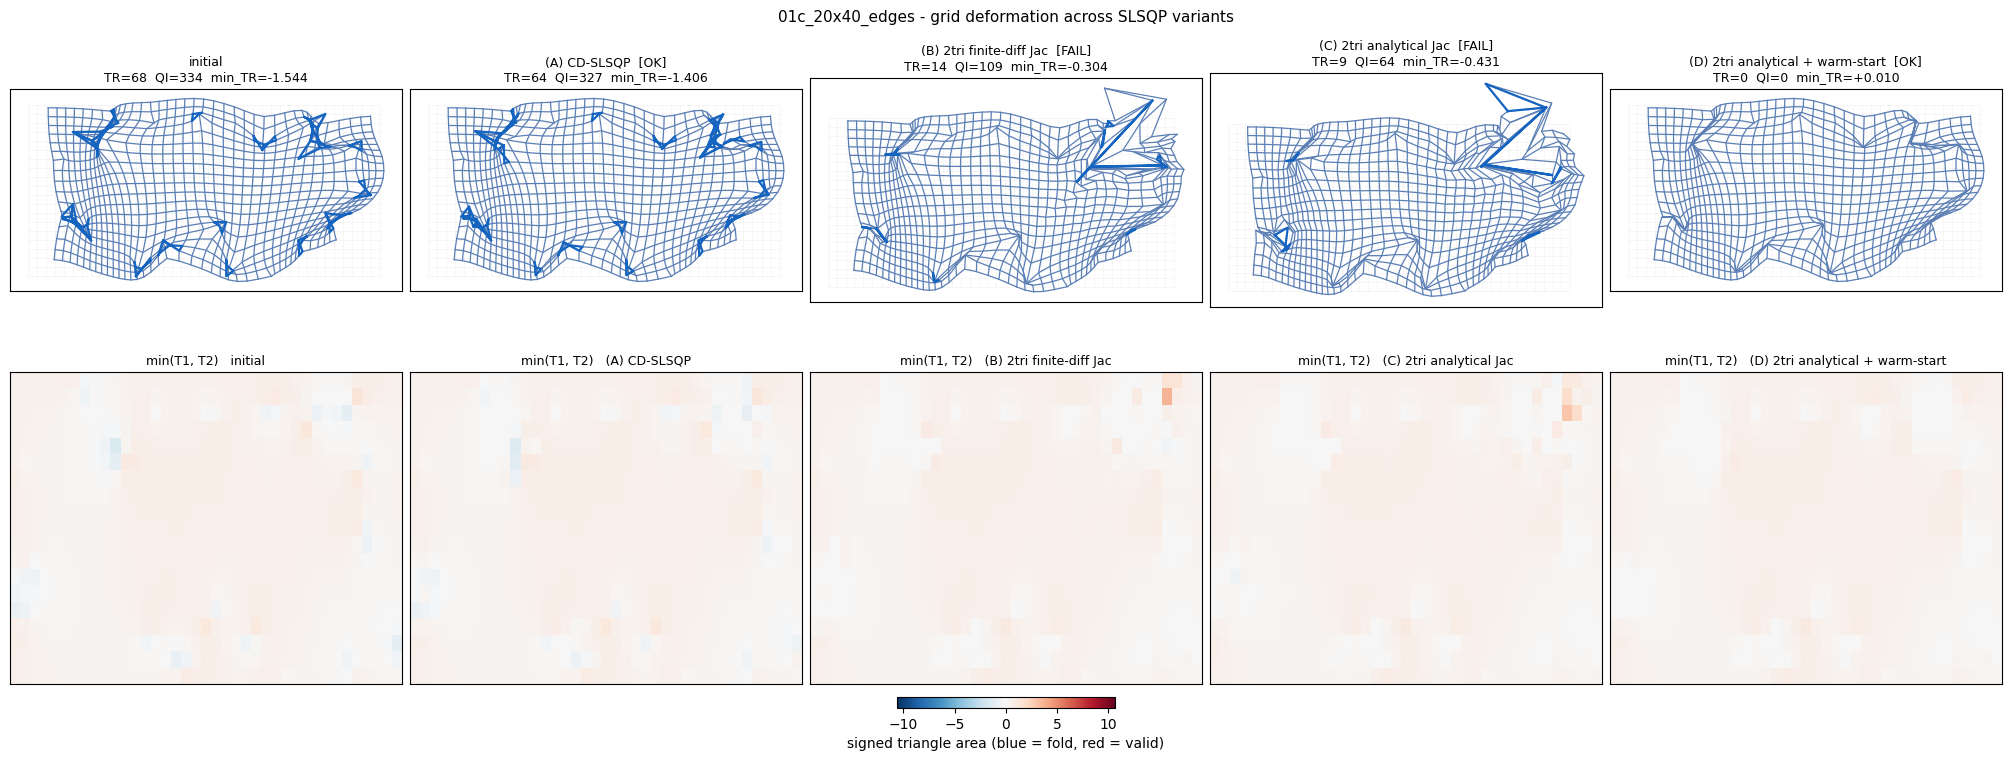

In [14]:
def plot_warped_grid(ax, phi, title, highlight_folds=True):
    dy = phi[0]; dx = phi[1]
    Hh, Ww = dy.shape
    yy, xx = np.mgrid[:Hh, :Ww]
    gx = xx + dx; gy = yy + dy
    for i in range(Hh):
        ax.plot(xx[i], yy[i], color='#f0f0f0', lw=0.4)
    for j in range(Ww):
        ax.plot(xx[:, j], yy[:, j], color='#f0f0f0', lw=0.4)
    for i in range(Hh):
        ax.plot(gx[i], gy[i], color='#5b7fb5', lw=0.9)
    for j in range(Ww):
        ax.plot(gx[:, j], gy[:, j], color='#5b7fb5', lw=0.9)
    if highlight_folds:
        tri = triangle_sign_areas2D(phi)
        bad = np.argwhere(tri.min(axis=0) <= 0)
        for (cy, cx) in bad:
            poly_x = [gx[cy, cx], gx[cy, cx+1], gx[cy+1, cx+1], gx[cy+1, cx], gx[cy, cx]]
            poly_y = [gy[cy, cx], gy[cy, cx+1], gy[cy+1, cx+1], gy[cy+1, cx], gy[cy, cx]]
            ax.plot(poly_x, poly_y, color='#1565c0', lw=1.6)
    ax.set_aspect('equal')
    ax.invert_yaxis()
    ax.set_title(title, fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])


variants = [
    ('initial',                          phi_init, m0,     len(qi_init), None),
    ('(A) CD-SLSQP',                     phi_cd,   m_cd,   len(qi_cd),   res_cd),
    ('(B) 2tri finite-diff Jac',         phi_fd,   m_fd,   len(qi_fd),   res_fd),
    ('(C) 2tri analytical Jac',          phi_an,   m_an,   len(qi_an),   res_an),
    ('(D) 2tri analytical + warm-start', phi_both, m_both, len(qi_both), res_both),
]

vmax = max(abs(m['tri']).max() for (_, _, m, _, _) in variants)
NL = chr(10)

n_var = len(variants)
fig, axes = plt.subplots(2, n_var, figsize=(4 * n_var, 7.5), layout='constrained')
for k, (label, phi, m, qi_n, res) in enumerate(variants):
    if res is None:
        line1 = label
    else:
        tag = 'OK' if res.success else 'FAIL'
        line1 = f'{label}  [{tag}]'
    line2 = f"TR={m['n_tr']}  QI={qi_n}  min_TR={m['min_tr']:+.3f}"
    plot_warped_grid(axes[0, k], phi, line1 + NL + line2)

    tri_min = m['tri'].min(axis=0)
    im = axes[1, k].imshow(tri_min, cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='auto')
    axes[1, k].set_title(f'min(T1, T2)   {label}', fontsize=9)
    axes[1, k].set_xticks([]); axes[1, k].set_yticks([])

cbar = fig.colorbar(im, ax=axes[1, :], orientation='horizontal',
                    fraction=0.035, pad=0.04, shrink=0.55)
cbar.set_label('signed triangle area (blue = fold, red = valid)')

plt.suptitle(f'{CASE_KEY} - grid deformation across SLSQP variants', fontsize=11)
plt.show()


### Per-pixel debug — grouped by pixel across variants

For the worst-offender pixels (smallest initial `min(T1, T2)`), one row each showing T1/T2 across the four variants. Red-filled triangles are valid; blue are flipped. Reading across a row shows how the same pixel's local geometry evolves as the SLSQP variant changes.

Capped at 6 pixels to keep the figure readable (01c_20x40_edges has 68+ problematic pixels at init).

top 6 worst pixels (by initial min_TR): [(10, 4), (10, 5), (33, 2), (38, 16), (16, 17), (1, 14)]


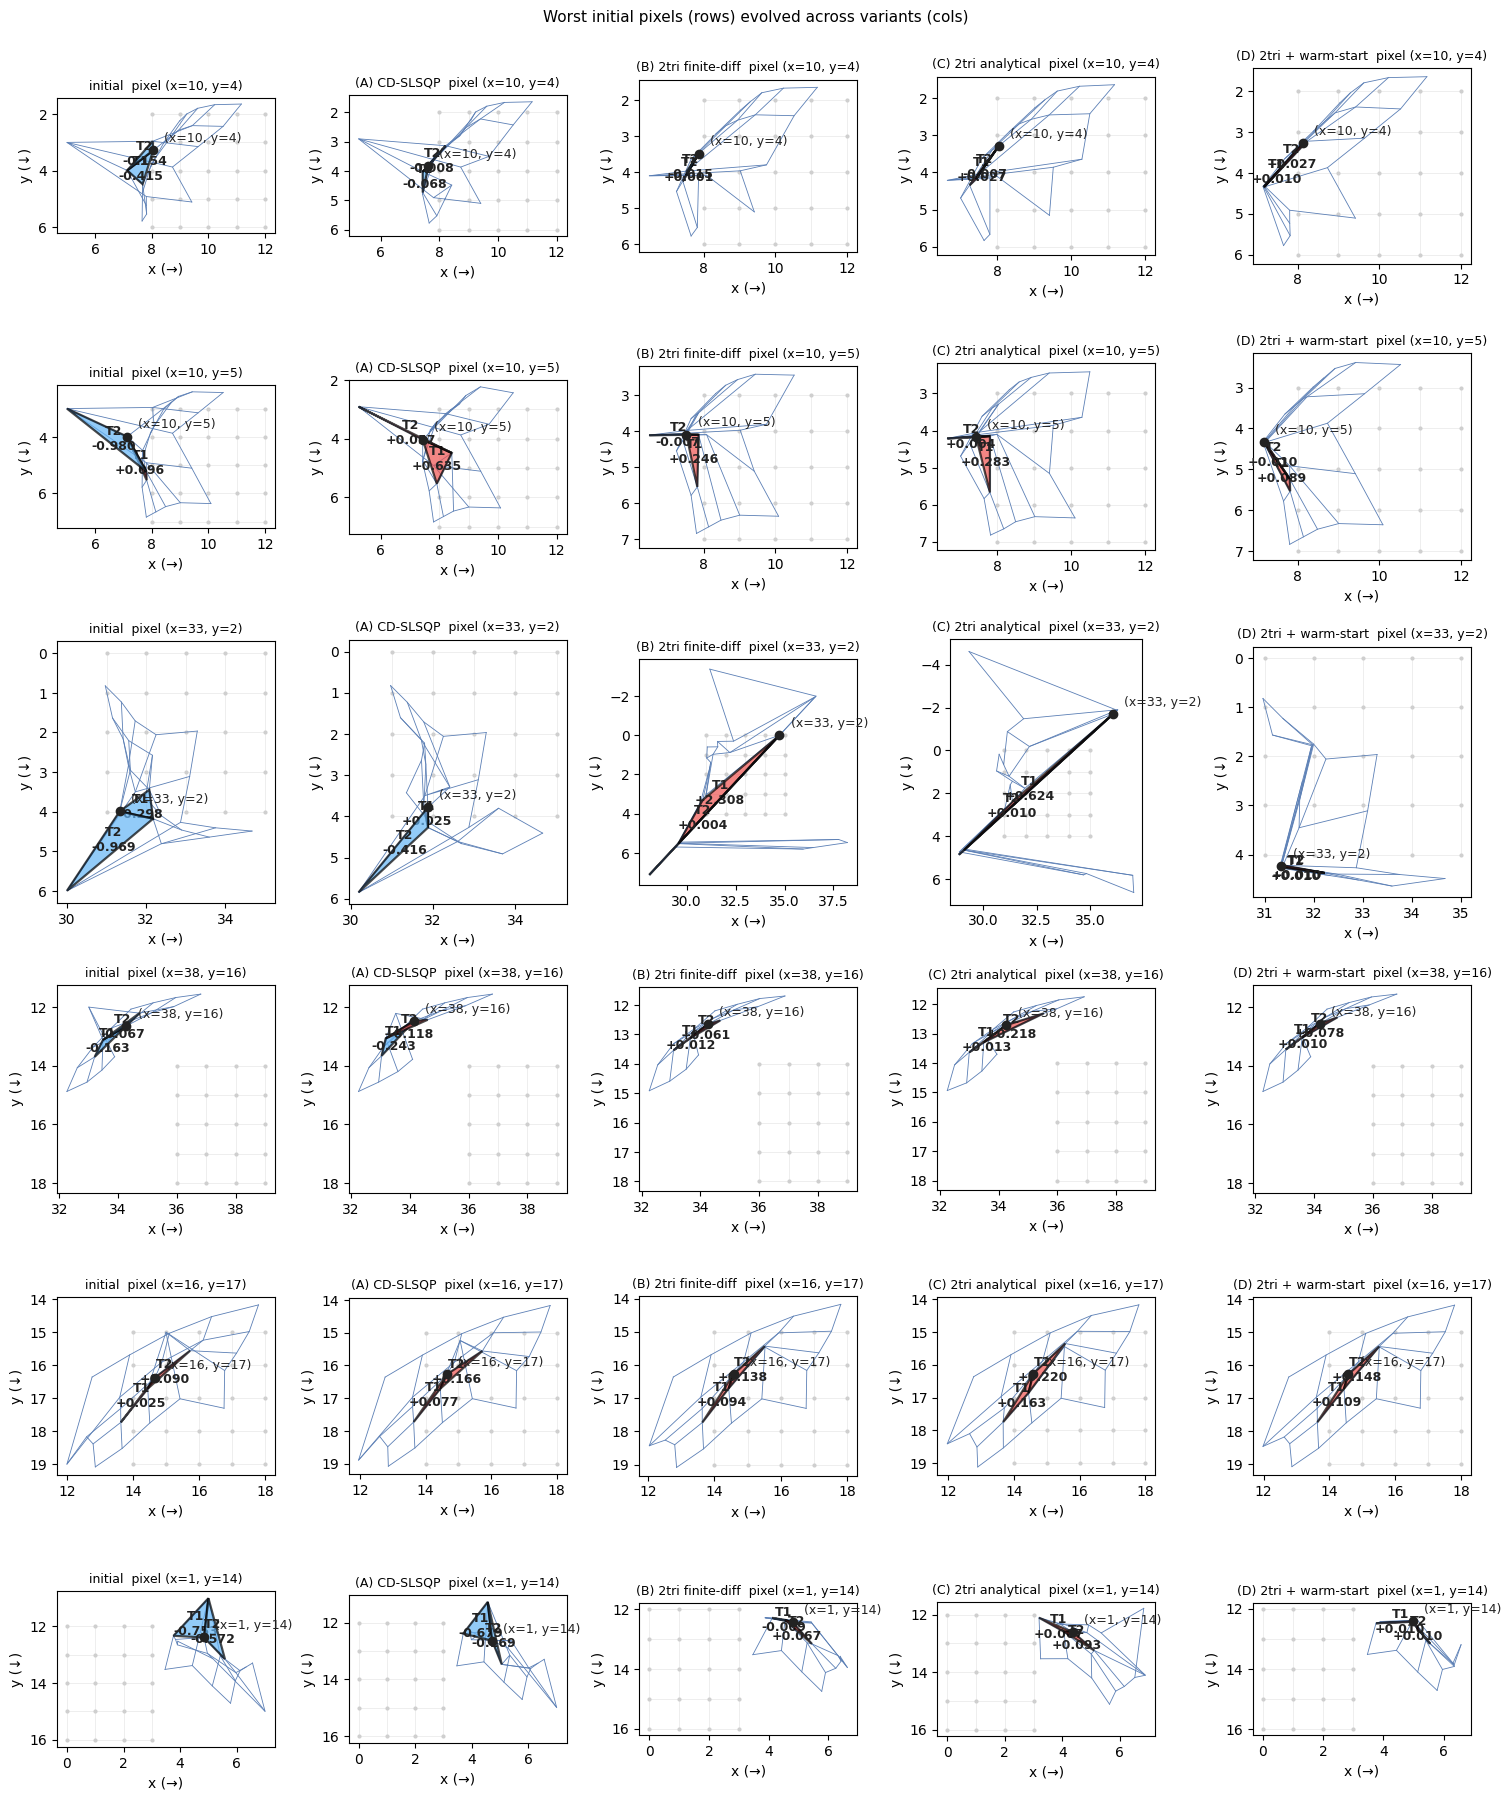

In [15]:
from dvfopt.viz.triangle_debug import find_problematic_pixels
from dvfopt.viz import plot_triangle_debug

labels = [
    ('initial',                  phi_init),
    ('(A) CD-SLSQP',             phi_cd),
    ('(B) 2tri finite-diff',     phi_fd),
    ('(C) 2tri analytical',      phi_an),
    ('(D) 2tri + warm-start',    phi_both),
]

K = 6
tri0 = triangle_sign_areas2D(phi_init)
tri0_min = tri0.min(axis=0)
worst_cells = np.argsort(tri0_min.ravel())[:K]
nr, nc = tri0_min.shape
worst_pixels = []
for flat in worst_cells:
    cy, cx = divmod(int(flat), nc)
    worst_pixels.append((cx if cx >= 1 else cx + 1, cy))
seen = set(); uniq = []
for p in worst_pixels:
    if p not in seen:
        seen.add(p); uniq.append(p)
worst_pixels = uniq[:K]
print(f'top {len(worst_pixels)} worst pixels (by initial min_TR):', worst_pixels)

fig, axes = plt.subplots(len(worst_pixels), len(labels),
                          figsize=(3.0 * len(labels), 3.0 * len(worst_pixels)),
                          layout='constrained', squeeze=False)
for row, (x, y) in enumerate(worst_pixels):
    for col, (label, phi) in enumerate(labels):
        plot_triangle_debug(phi, x=x, y=y, ax=axes[row, col], show_formula=False)
        axes[row, col].set_title(f'{label}  pixel (x={x}, y={y})', fontsize=9)
plt.suptitle('Worst initial pixels (rows) evolved across variants (cols)', fontsize=11)
plt.show()


## Summary

- **Part 4 diagnosis**: SLSQP stalls at `nit=42` with status 8 (*"Positive directional derivative for linesearch"*). Raising `maxiter` and tightening `ftol` does nothing — not a budget issue. The QP sub-problem's line search can't find a descent direction.
- **Part 4 fix**: warm-start from the stuck iterate with σ=0.01 Gaussian perturbation. Breaks the degenerate direction — SLSQP re-converges to `neg_TR=0`, `QI=0`, `success=True`.
- **Part 5 derivation**: the 2-triangle signed area is a polynomial so `∂T/∂z` is closed-form. Six nonzeros per constraint row. Validated to FD step-floor precision (rel err ~3e-7).
- **Part 5 head-to-head** on `01c_20x40_edges`:

  | variant | nit | time | neg_TR | QI | success |
  |---|---:|---:|---:|---:|:---:|
  | finite-diff Jac (baseline) | 42 | ~104s | 14 | 109 | False |
  | analytical Jac | 29 | ~78s | 9 | 64 | False |
  | **analytical Jac + warm-start** | 80 | ~169s | **0** | **0** | **True** |

- **Conclusions:**
  1. Analytical Jacobian alone is strictly better but not sufficient here — it reduces the failure (more progress per iter, faster) but SLSQP still hits the line-search degeneracy.
  2. Perturbation warm-start alone is what unsticks the solver; analytical Jacobian composes with it.
  3. For a robust SLSQP corrector, **use both**: analytical Jacobian from the start, with a status-8 catch that re-runs with `phi_out + noise`.

- **Next step**: promote `triangle_sign_constraint_jac_2d` from this notebook into [dvfopt/jacobian/triangle_sign.py](../../dvfopt/jacobian/triangle_sign.py) alongside `triangle_sign_constraint`, matching the pattern used by `shoelace_constraint_jacobian_2d`.